In [1]:
import cv2
import numpy as np
import pytesseract
from deskew import determine_skew
from PIL import Image

Algorithm predicted skew angle: 8.0000 degrees


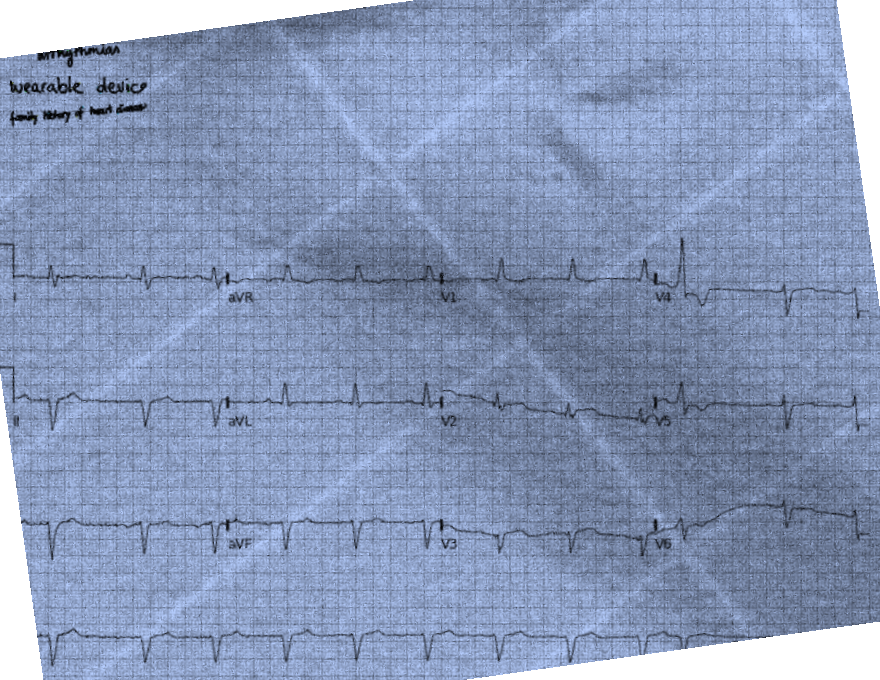

In [2]:
def manual_deskew(image_path: str):
    # 1. Load the image using PIL
    pil_image = Image.open(image_path)

    # 2. Convert to numpy array for calculating the skew
    img_np = np.array(pil_image)

    # 3. Create a grayscale variant for the deskew algorithm
    if len(img_np.shape) == 3 and img_np.shape[2] >= 3:
        grayscale = np.mean(img_np[:, :, :3], axis=2).astype(np.uint8)
    else:
        grayscale = img_np

    # 4. Extract purely the predicted angle mapping
    predicted_angle = determine_skew(grayscale, max_angle=45.0, num_peaks=20)
    print(f"Algorithm predicted skew angle: {predicted_angle:.4f} degrees")

    if predicted_angle is None or abs(predicted_angle) < 0.1:
        print("No significant skew detected. Returning original image.")
        return pil_image

    # 5. Apply the rotation yourself using PIL - keeping expand=False prevents the aggressive cropping
    rotated_img = pil_image.rotate(
        predicted_angle,
        resample=Image.Resampling.BILINEAR,
        expand=False,
        fillcolor=(255, 255, 255),
    )

    return rotated_img


# Test it out
fixed_img = manual_deskew("../data/train/ecg_train_0031.png")
display(fixed_img)

In [ ]:
def mask_text_morphology(pil_image: Image.Image, fill_color=(255, 255, 255)):
    """
    Detects text using morphological operations (UMMISCO/ecgtizer approach)
    and draws bounding boxes filled with `fill_color` over the detected text regions
    to "erase" them before processing.
    """
    # 1. Convert to numpy array
    img_np = np.array(pil_image)
    if len(img_np.shape) == 3:
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    else:
        gray = img_np

    height, width = gray.shape

    # 2. Gaussian blur to smooth things out
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # 3. OTSU Binarization, Inverted (text becomes white on black background)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 4. Dynamic Dilation Kernel
    # The ecgtizer uses a dynamic kernel size to crash characters together into word-blocks
    kernel_size = int(0.0075 * min(height, width))
    # Ensure kernel size is at least 1 and odd (optional but good practice)
    if kernel_size < 1:
        kernel_size = 1
    rect_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (kernel_size * 2, kernel_size)
    )

    # 5. Dilate to merge text into blocks
    dilated = cv2.dilate(thresh, rect_kernel, iterations=1)

    # 6. Find Contours
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    masked_img_np = img_np.copy()

    # 7. Erasing Heuristics
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)

        # Heuristic: If block height is less than image_width / 4
        # AND block width is less than image_height / 3
        # This stops the algorithm from deleting massive straight signal traces and long ECG grids
        if h < (width / 4) and w < (height / 3):
            # Fill the bounding box with white
            masked_img_np[y : y + h, x : x + w] = fill_color

    return Image.fromarray(masked_img_np)


In [ ]:
def mask_text_before_binarize(pil_image: Image.Image, fill_color=(255, 255, 255)):
    """
    Detects text using pytesseract and draws bounding boxes filled with `fill_color`
    over the detected text regions to "erase" them before processing.
    """
    # 1. Convert to CV2 compatible array
    img_np = np.array(pil_image)
    if len(img_np.shape) == 3:
        img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
    else:
        img_bgr = cv2.cvtColor(img_np, cv2.COLOR_GRAY2BGR)

    # 2. Extract bounding box data from tesseract
    # Dictionary output gives us left, top, width, height for each detected character/word
    data = pytesseract.image_to_data(img_np, output_type=pytesseract.Output.DICT)

    masked_img_np = img_np.copy()

    # 3. Iterate through every detected text element
    n_boxes = len(data["text"])
    for i in range(n_boxes):
        # Filter out empty text / low confidence detections (optional, could adjust confidence threshold)
        if int(data["conf"][i]) > 10:
            (x, y, w, h) = (
                data["left"][i],
                data["top"][i],
                data["width"][i],
                data["height"][i],
            )

            # 4. Fill the bounding box with white (or the background color)
            # Add a small padding to ensure we catch descenders/ascenders
            pad = 2
            cv2.rectangle(
                masked_img_np,
                (x - pad, y - pad),
                (x + w + pad, y + h + pad),
                fill_color,
                -1,
            )

    return Image.fromarray(masked_img_np)


In [ ]:
from binarize import adaptive_binarize, color_filter_binarize, otsu_binarize
from debug import *

img = manual_deskew("../data/test/ecg_test_0001.png")

# img = color_filter_binarize(img)

# show_chop(img, header_frac=0.25)
# show_extraction(
#     img,
#     binarize="canny",
# )


# show_segmentation(img)
# show_extraction(img)
# show_grid_detection(img)

Algorithm predicted skew angle: 0.0000 degrees
No significant skew detected. Returning original image.


In [ ]:
from extract import digitize
from plot import plot_ecg

img = manual_deskew("../data/train/ecg_train_0001.png")
display(img)
leads = digitize(img)

plot_ecg(leads)

# for lead in leads:
#     print(leads[lead].shape)

Algorithm predicted skew angle: 8.0000 degrees


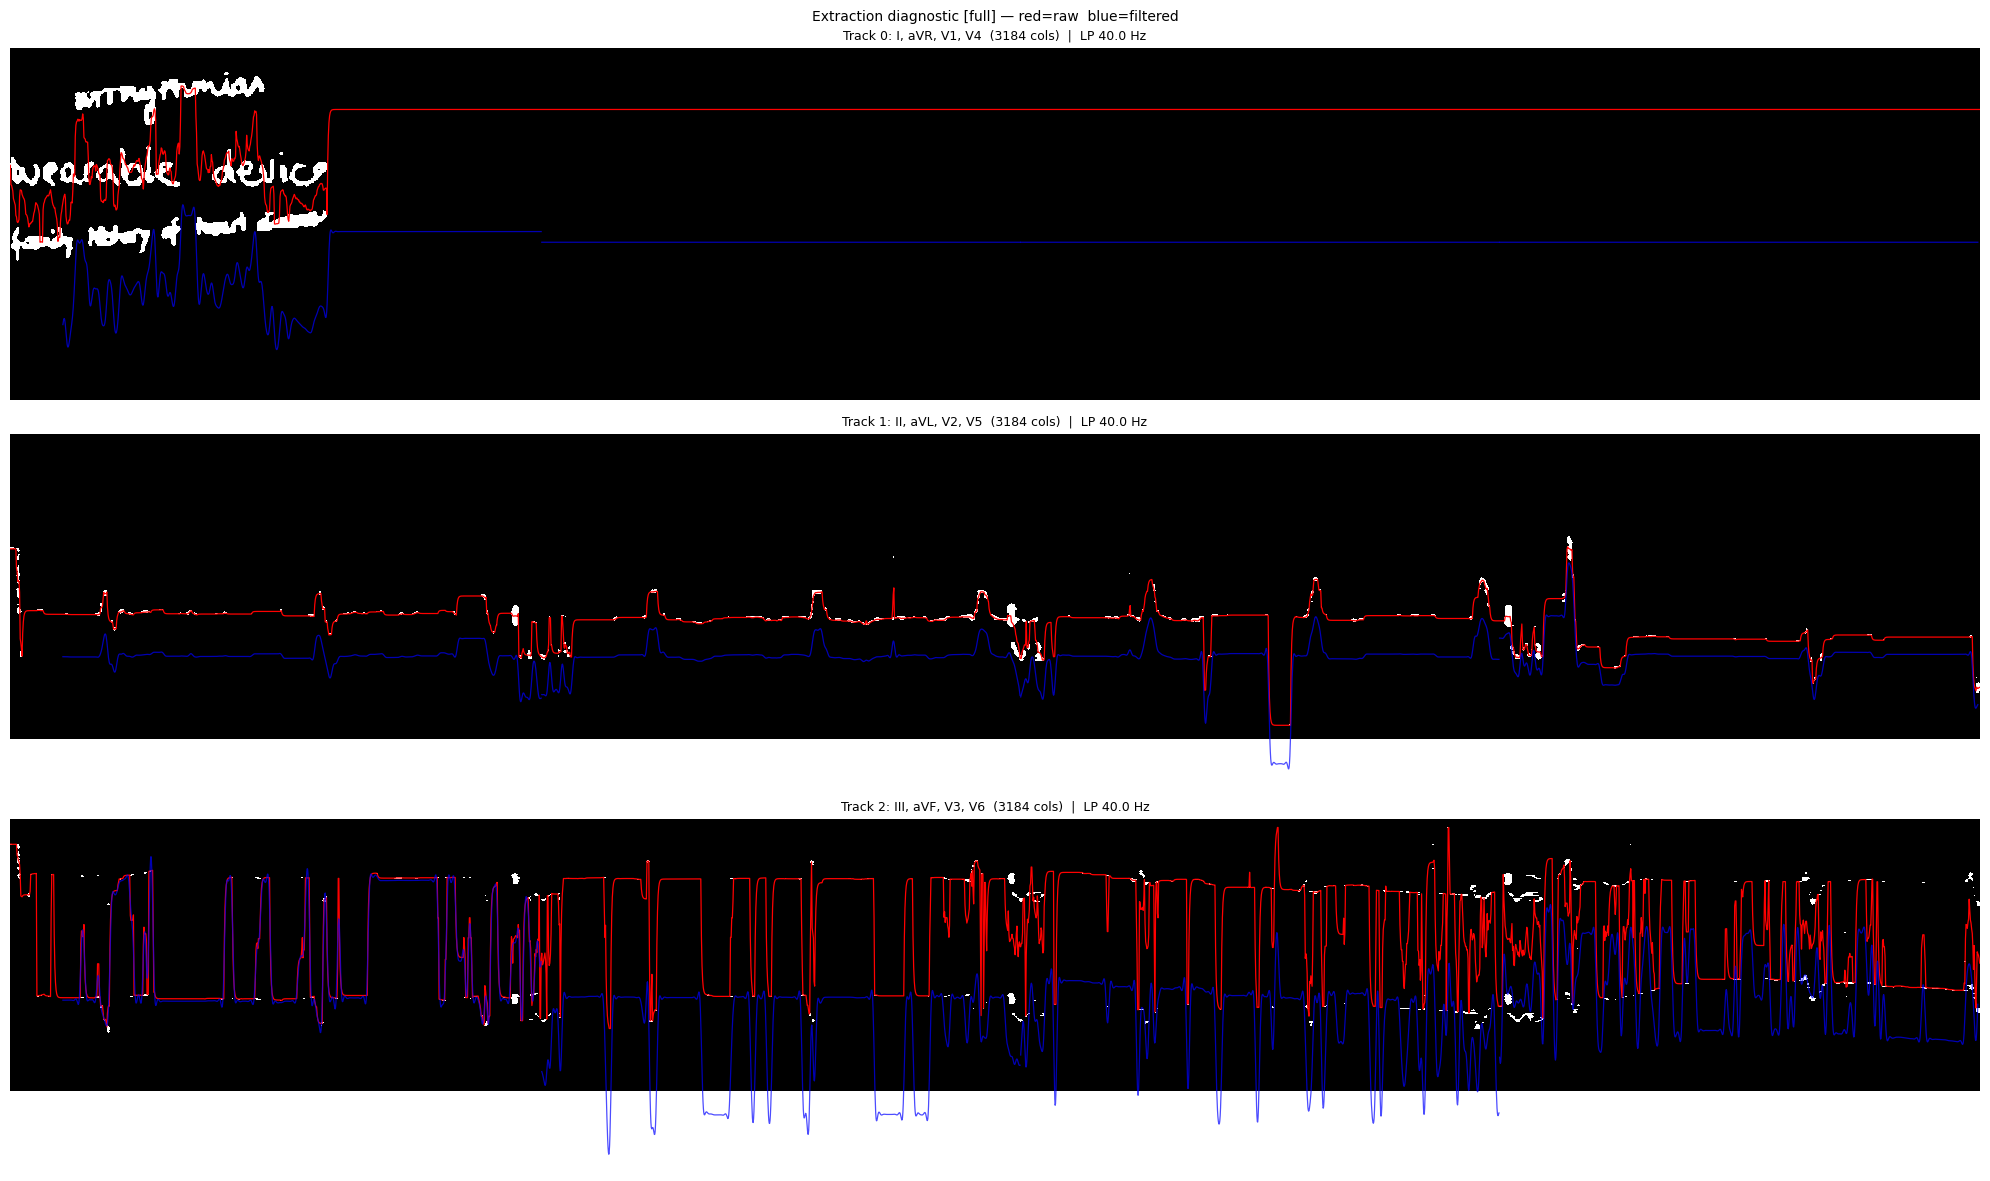

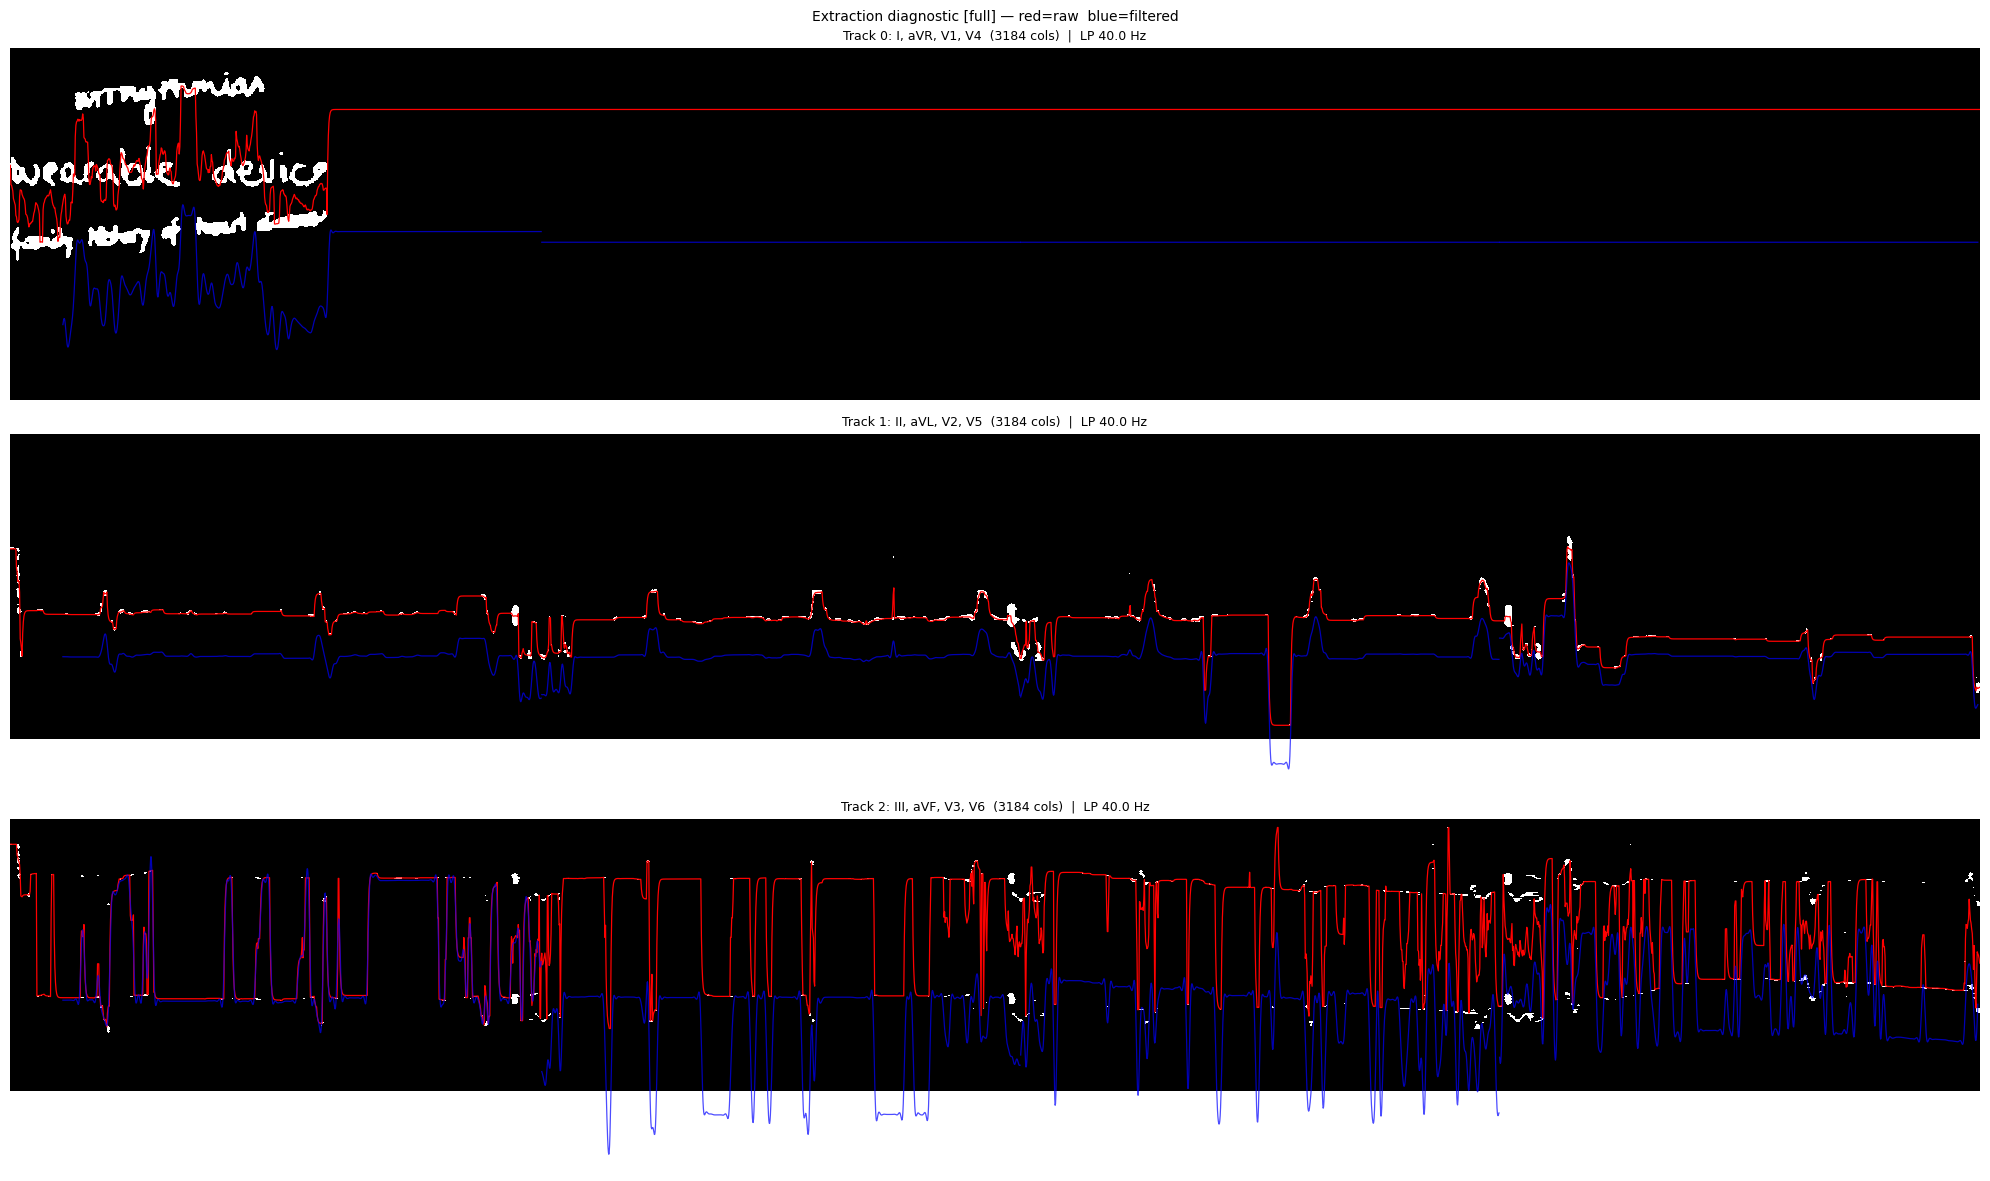

In [ ]:
from extract import standardize
from debug import show_extraction

img = manual_deskew("../data/train/ecg_train_0031.png")
# binary = standardize(img, binarize="color")
# display(img)

# Best general-purpose combo
show_extraction(
    img,
    binarize="color",
    extract_method="full",
    mask_text_first=True,
)